In [1]:
import pandas as pd
import numpy as np
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

def add_features(df):
    df = df.copy()
    for col in ["plan_tier", "region", "is_autopay", "is_discounted", "has_family_bundle"]:
        df[col] = df[col].astype(str)
    df["engagement_rate"]   = (df["active_days"] / 30.0).clip(0, 1)
    df["usage_per_login"]   = df["monthly_usage_hours"] / (df["login_count"] + 1e-3)
    df["support_intensity"] = df["support_tickets"] + 3 * df["sla_breaches"]
    df["email_ctr"]         = df["email_clicks"] / (df["email_opens"] + 1e-3)
    df["price_to_tenure"]   = df["billing_amount"] / (df["tenure_months"] + 1e-3)
    return df

TARGET  = "churned_next_cycle"
EXCLUDE = [TARGET, "cycle_start", "cycle_end", "customer_id"]

df = add_features(pd.read_parquet("../data/churn_frame.parquet"))
df = df.sort_values("cycle_start").reset_index(drop=True)

X = df.drop(columns=EXCLUDE)
y = df[TARGET]

preprocessor = joblib.load("../models/preprocessor.joblib")

# Chronological 80/20 split
split_idx = int(len(X) * 0.80)
X_tr, X_va = X.iloc[:split_idx], X.iloc[split_idx:]
y_tr, y_va = y.iloc[:split_idx], y.iloc[split_idx:]

# Imbalance ratio for scale_pos_weight
spw = int(y_tr.value_counts()[0] / y_tr.value_counts()[1])
print(f"scale_pos_weight = {spw}")
print(f"Train: {X_tr.shape}, Val: {X_va.shape}")

scale_pos_weight = 7
Train: (6400, 26), Val: (1600, 26)


In [2]:
def objective(trial):
    params = dict(
        n_estimators       = trial.suggest_int("n_estimators", 200, 800),
        max_depth          = trial.suggest_int("max_depth", 3, 8),
        learning_rate      = trial.suggest_float("lr", 0.01, 0.2, log=True),
        subsample          = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree   = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda         = trial.suggest_float("reg_lambda", 0.0, 5.0),
        reg_alpha          = trial.suggest_float("reg_alpha", 0.0, 2.0),
        scale_pos_weight   = spw,
        tree_method        = "hist",
        random_state       = 42,
        n_jobs             = -1,
        eval_metric        = "aucpr",
    )
    pipe = Pipeline([("pre", preprocessor), ("clf", XGBClassifier(**params))])
    pipe.fit(X_tr, y_tr,
             clf__eval_set=[(preprocessor.transform(X_va), y_va)],
             clf__verbose=False)
    proba = pipe.predict_proba(X_va)[:, 1]
    return average_precision_score(y_va, proba)

print("✅ Objective defined — running 30 trials...")

✅ Objective defined — running 30 trials...


In [3]:
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ Best PR-AUC: {study.best_value:.4f}")
print(f"\nBest params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best PR-AUC: 0.2592

Best params:
  n_estimators: 409
  max_depth: 3
  lr: 0.025055456788528226
  subsample: 0.8377121162156264
  colsample_bytree: 0.8461189733611159
  reg_lambda: 0.1989538046215115
  reg_alpha: 0.9321468314684377


In [4]:
best = study.best_params
best.update({"scale_pos_weight": spw, "tree_method": "hist",
             "random_state": 42, "n_jobs": -1, "eval_metric": "aucpr"})

final_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", XGBClassifier(**best))
])

# Isotonic calibration improves probability reliability (Brier score)
# cv=3 uses 3-fold CV internally to fit calibration
calibrated = CalibratedClassifierCV(final_pipe, method="isotonic", cv=3)
calibrated.fit(X_tr, y_tr)

proba_cal = calibrated.predict_proba(X_va)[:, 1]
pr_auc  = average_precision_score(y_va, proba_cal)
roc_auc = roc_auc_score(y_va, proba_cal)

print("=== Final Calibrated XGBoost ===")
print(f"  PR-AUC:  {pr_auc:.4f}")
print(f"  ROC-AUC: {roc_auc:.4f}")

=== Final Calibrated XGBoost ===
  PR-AUC:  0.2137
  ROC-AUC: 0.6856


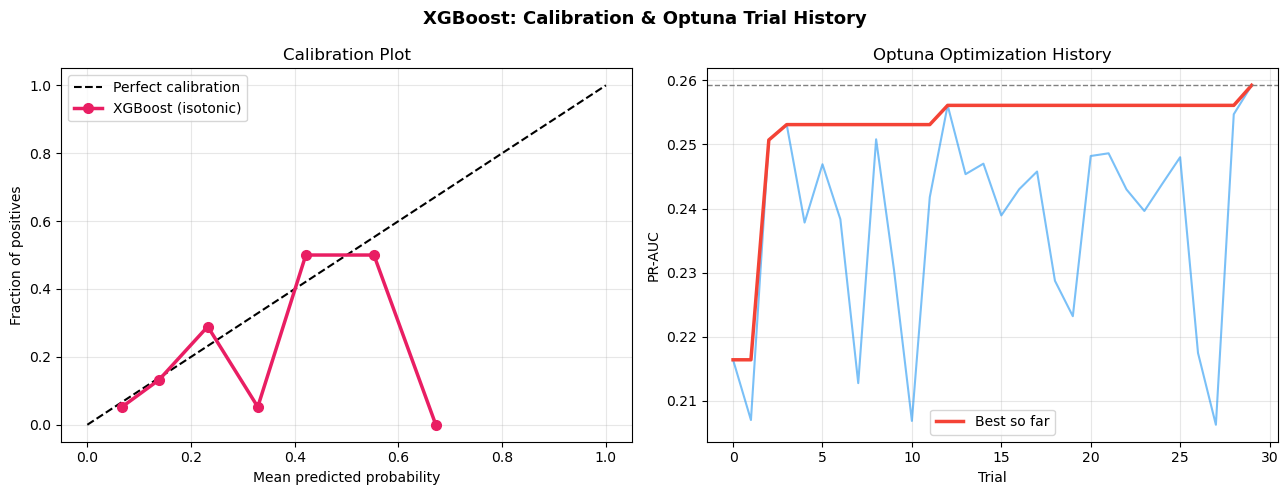

In [5]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("XGBoost: Calibration & Optuna Trial History", fontsize=13, fontweight='bold')

# Calibration curve
frac_pos, mean_pred = calibration_curve(y_va, proba_cal, n_bins=10)
ax1.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration")
ax1.plot(mean_pred, frac_pos, "o-", color="#E91E63", lw=2.5, ms=7, label="XGBoost (isotonic)")
ax1.set_xlabel("Mean predicted probability")
ax1.set_ylabel("Fraction of positives")
ax1.set_title("Calibration Plot")
ax1.legend(); ax1.grid(alpha=0.3)

# Optuna trial history
trial_values = [t.value for t in study.trials if t.value is not None]
ax2.plot(trial_values, color="#2196F3", lw=1.5, alpha=0.6)
ax2.plot(np.maximum.accumulate(trial_values), color="#F44336", lw=2.5, label="Best so far")
ax2.axhline(y=max(trial_values), color="gray", ls="--", lw=1)
ax2.set_xlabel("Trial"); ax2.set_ylabel("PR-AUC")
ax2.set_title("Optuna Optimization History"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/xgboost_calibration.png", dpi=120, bbox_inches='tight')
plt.show()

In [6]:
joblib.dump(calibrated, "../models/churn_calibrated.joblib")
print(f"✅ Model saved → ../models/churn_calibrated.joblib")
print(f"   Size: {__import__('os').path.getsize('../models/churn_calibrated.joblib')/1024:.1f} KB")
print(f"\nFinal metrics:")
print(f"  PR-AUC:  {pr_auc:.4f}")
print(f"  ROC-AUC: {roc_auc:.4f}")

✅ Model saved → ../models/churn_calibrated.joblib
   Size: 1414.2 KB

Final metrics:
  PR-AUC:  0.2137
  ROC-AUC: 0.6856
